# Experiment 1: Single Layer Perceptron for Binary Classification
### CS3807 – Deep Learning Laboratory
**Dataset:** Banknote Authentication Dataset (UCI ML Repository)

This notebook follows the lab manual exactly, task by task, from dataset exploration through
the perceptron implementation, training, evaluation, learning-rate comparison, decision boundary,
and the additional discussion tasks.

## 0. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## Task 1: Dataset Exploration

Columns (per UCI documentation): `variance`, `skewness`, `curtosis`, `entropy`, `class`
(0 = Authentic, 1 = Forged).

In [2]:
columns = ["variance", "skewness", "curtosis", "entropy", "class"]
df = pd.read_csv("data_banknote_authentication.txt", header=None, names=columns)
df.head()


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:
print("Dataset dimensions (rows, columns):", df.shape)


Dataset dimensions (rows, columns): (1372, 5)


In [4]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


In [5]:
df.describe()


,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [6]:
print("Class distribution:")
print(df["class"].value_counts())


Class distribution:
class
0    762
1    610
Name: count, dtype: int64


## Task 2: Exploratory Data Analysis

### Plot 1: Feature Histograms

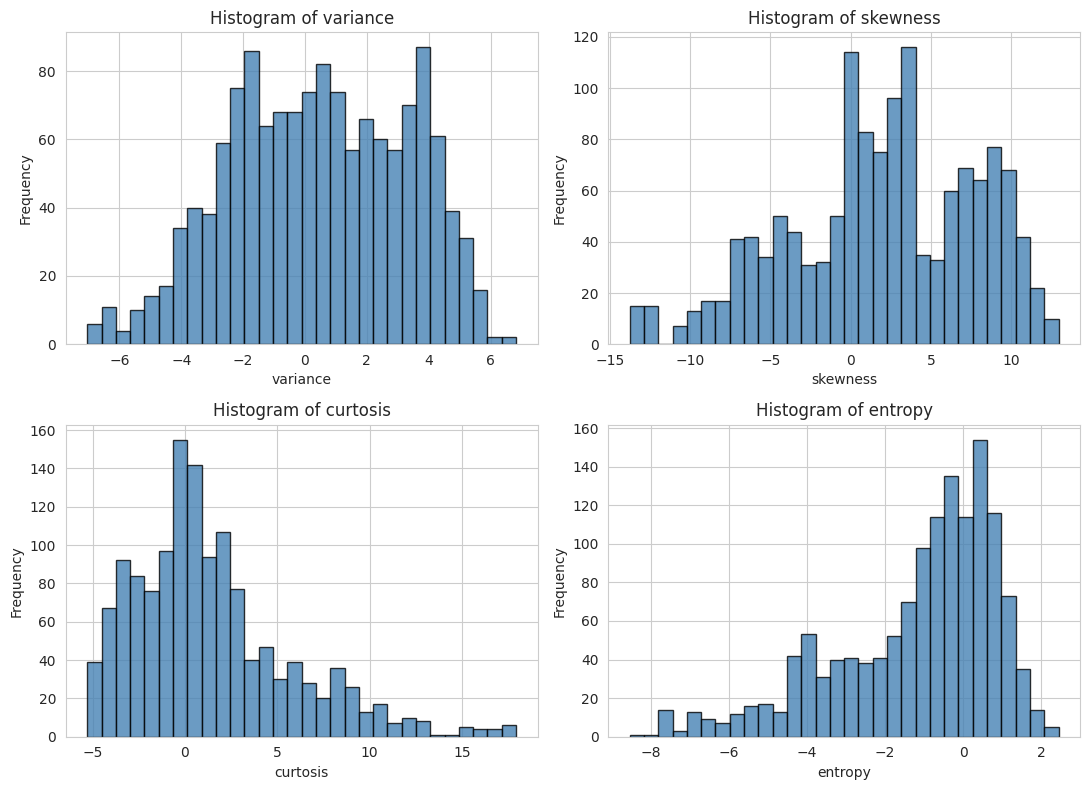

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
features = ["variance", "skewness", "curtosis", "entropy"]
for ax, feat in zip(axes.flatten(), features):
    ax.hist(df[feat], bins=30, color="steelblue", edgecolor="black", alpha=0.8)
    ax.set_title(f"Histogram of {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("plot_histograms.png", dpi=120)
plt.show()


**Interpretation:** `variance` and `skewness` show reasonably spread, somewhat bimodal
distributions (consistent with two underlying classes), while `curtosis` and `entropy` are more
concentrated with heavier tails/outliers on one side, indicating skewed distributions for those
two features.

### Plot 2: Correlation Heatmap

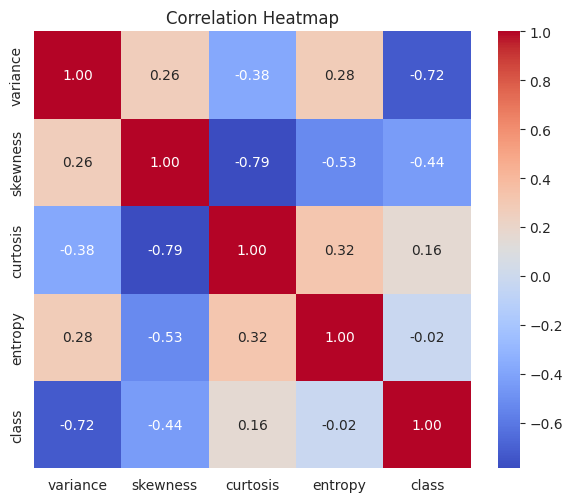

In [8]:
plt.figure(figsize=(6, 5))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plot_corr_heatmap.png", dpi=120)
plt.show()


**Interpretation:** `variance` has the strongest (negative) correlation with `class`,
suggesting it is the most discriminative single feature. `skewness` and `curtosis` are also
correlated with each other, indicating some redundancy between them.

### Plot 3: Scatter Plot (Class Distribution)

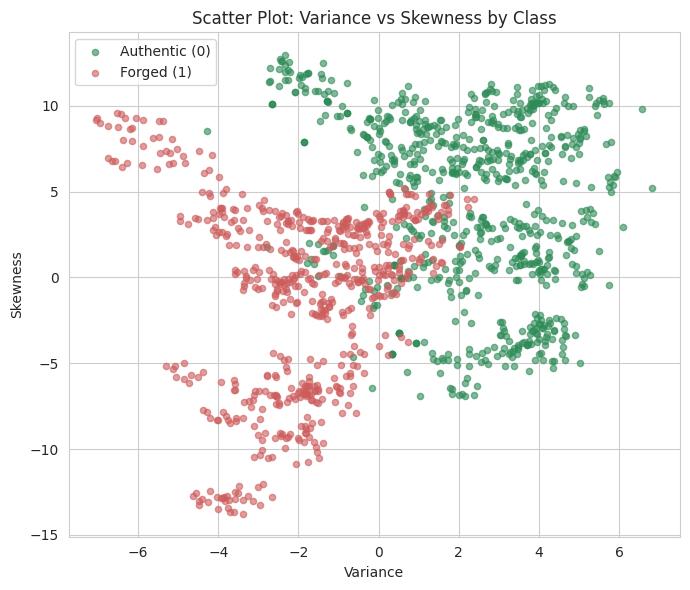

In [9]:
plt.figure(figsize=(7, 6))
for cls, color, label in [(0, "seagreen", "Authentic (0)"), (1, "indianred", "Forged (1)")]:
    subset = df[df["class"] == cls]
    plt.scatter(subset["variance"], subset["skewness"], c=color, label=label, alpha=0.6, s=20)
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Scatter Plot: Variance vs Skewness by Class")
plt.legend()
plt.tight_layout()
plt.savefig("plot_scatter.png", dpi=120)
plt.show()


**Interpretation:** The two classes show substantial, though not perfect, separation along
the variance/skewness plane — a diagonal boundary roughly separates most authentic from forged
notes, suggesting the data is close to linearly separable in this projection, which is promising
for a perceptron.

### Plot 4: Boxplots

/tmp/ipykernel_531/860892882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="class", y=feat, data=df, ax=ax, palette=["seagreen", "indianred"])
/tmp/ipykernel_531/860892882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="class", y=feat, data=df, ax=ax, palette=["seagreen", "indianred"])
/tmp/ipykernel_531/860892882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="class", y=feat, data=df, ax=ax, palette=["seagreen", "indianred"])
/tmp/ipykernel_531/860892882.py:3: FutureWarning: 

Passing `palette` without assigning `hue` 

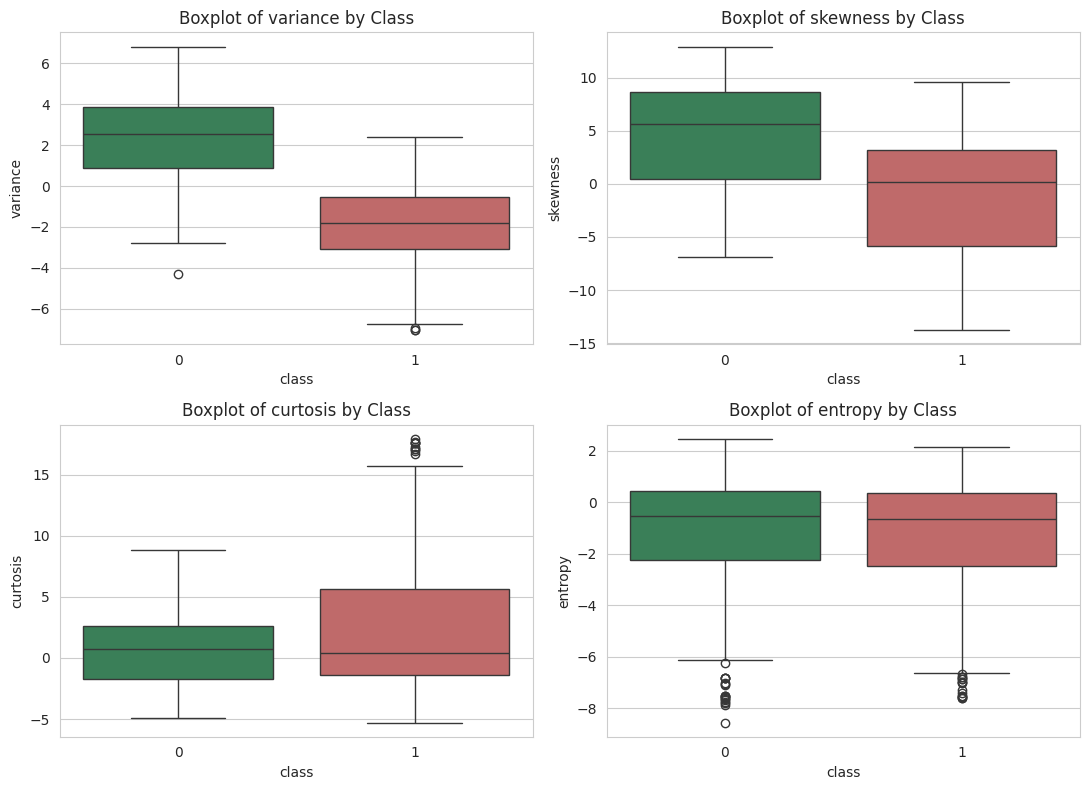

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feat in zip(axes.flatten(), features):
    sns.boxplot(x="class", y=feat, data=df, ax=ax, palette=["seagreen", "indianred"])
    ax.set_title(f"Boxplot of {feat} by Class")
plt.tight_layout()
plt.savefig("plot_boxplots.png", dpi=120)
plt.show()


**Interpretation:** `variance` shows the clearest separation in medians between the two
classes with limited overlap, while `entropy` shows heavy overlap between classes, implying it
alone is a weak discriminator. A few outliers are visible in `curtosis` and `entropy`.

## Task 3: Data Preprocessing

Normalize all numerical features (zero mean, unit variance) and split 80/20 into train/test sets.

In [11]:
X = df[features].values
y = df["class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (1097, 4)
Testing set shape: (275, 4)


## Task 4: Perceptron Implementation (from scratch)

Implements weight/bias initialization, the step activation function, forward propagation, and the
perceptron learning rule, exactly as specified in the manual:

$$z = w^Tx + b \qquad \hat y = f(z) \qquad w_{new} = w_{old} + \eta(y-\hat y)x \qquad b_{new} = b_{old} + \eta(y-\hat y)$$


In [12]:
class Perceptron:
    def __init__(self, n_features, learning_rate=0.01, n_epochs=50):
        self.lr = learning_rate
        self.n_epochs = n_epochs
        # Weight and bias initialization
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        # History for analysis / plotting
        self.history = {"epoch": [], "errors": [], "weights": [], "bias": []}

    @staticmethod
    def step_activation(z):
        return np.where(z >= 0, 1, 0)

    def forward(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.step_activation(z)

    def fit(self, X, y, verbose=True):
        n_samples = X.shape[0]
        for epoch in range(1, self.n_epochs + 1):
            misclassified = 0
            for xi, yi in zip(X, y):
                z = np.dot(xi, self.weights) + self.bias
                y_hat = self.step_activation(z)
                error = yi - y_hat
                if error != 0:
                    misclassified += 1
                    # Perceptron learning rule
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error

            self.history["epoch"].append(epoch)
            self.history["errors"].append(misclassified)
            self.history["weights"].append(self.weights.copy())
            self.history["bias"].append(self.bias)

            if verbose:
                print(f"Epoch {epoch:3d} | Misclassified: {misclassified:4d} | "
                      f"Weights: {np.round(self.weights, 4)} | Bias: {round(self.bias, 4)}")

            if misclassified == 0:
                if verbose:
                    print(f"\nConverged at epoch {epoch} (zero misclassifications).")
                break

    def predict(self, X):
        return self.forward(X)


## Task 5: Model Training

Train with learning rate $\eta = 0.01$ for up to 100 epochs, printing per-epoch diagnostics.

In [13]:
model = Perceptron(n_features=X_train.shape[1], learning_rate=0.01, n_epochs=100)
model.fit(X_train, y_train, verbose=True)


Epoch   1 | Misclassified:   51 | Weights: [-0.0602 -0.0841 -0.063   0.0023] | Bias: -0.03
Epoch   2 | Misclassified:   32 | Weights: [-0.0863 -0.1022 -0.0766  0.0074] | Bias: -0.03
Epoch   3 | Misclassified:   27 | Weights: [-0.0993 -0.1133 -0.082   0.0055] | Bias: -0.04
Epoch   4 | Misclassified:   25 | Weights: [-0.0799 -0.1184 -0.1063 -0.0073] | Bias: -0.05
Epoch   5 | Misclassified:   27 | Weights: [-0.1099 -0.1249 -0.1031 -0.0068] | Bias: -0.04
Epoch   6 | Misclassified:   20 | Weights: [-0.1045 -0.1264 -0.1146  0.0109] | Bias: -0.06
Epoch   7 | Misclassified:   20 | Weights: [-0.107  -0.1469 -0.1033  0.0077] | Bias: -0.06
Epoch   8 | Misclassified:   23 | Weights: [-0.1152 -0.1481 -0.1144 -0.0082] | Bias: -0.05
Epoch   9 | Misclassified:   21 | Weights: [-0.1152 -0.1396 -0.1341 -0.0017] | Bias: -0.06
Epoch  10 | Misclassified:   22 | Weights: [-0.1303 -0.1585 -0.1233 -0.0066] | Bias: -0.06
Epoch  11 | Misclassified:   18 | Weights: [-0.1252 -0.166  -0.1295 -0.001 ] | Bias: -0.06

Epoch  46 | Misclassified:   14 | Weights: [-0.191  -0.224  -0.1908 -0.0025] | Bias: -0.1
Epoch  47 | Misclassified:   13 | Weights: [-0.1893 -0.2159 -0.2095 -0.011 ] | Bias: -0.09
Epoch  48 | Misclassified:   14 | Weights: [-0.1866 -0.2159 -0.2167 -0.0077] | Bias: -0.09
Epoch  49 | Misclassified:   16 | Weights: [-0.1963 -0.2207 -0.2053 -0.014 ] | Bias: -0.09
Epoch  50 | Misclassified:   16 | Weights: [-0.204  -0.2218 -0.1995 -0.0226] | Bias: -0.09


Epoch  51 | Misclassified:   16 | Weights: [-0.2005 -0.2345 -0.1979 -0.0136] | Bias: -0.09
Epoch  52 | Misclassified:   17 | Weights: [-0.1842 -0.2431 -0.2068 -0.026 ] | Bias: -0.1
Epoch  53 | Misclassified:   16 | Weights: [-0.1897 -0.2364 -0.2109 -0.0271] | Bias: -0.1
Epoch  54 | Misclassified:   20 | Weights: [-0.1993 -0.2459 -0.202  -0.0137] | Bias: -0.1
Epoch  55 | Misclassified:   17 | Weights: [-0.1815 -0.2486 -0.2181 -0.012 ] | Bias: -0.11
Epoch  56 | Misclassified:   15 | Weights: [-0.1898 -0.246  -0.219  -0.0211] | Bias: -0.1
Epoch  57 | Misclassified:   17 | Weights: [-0.1963 -0.2377 -0.218  -0.0299] | Bias: -0.11
Epoch  58 | Misclassified:   17 | Weights: [-0.1968 -0.2421 -0.2188 -0.0244] | Bias: -0.1
Epoch  59 | Misclassified:   18 | Weights: [-0.1987 -0.2368 -0.2252 -0.0241] | Bias: -0.1
Epoch  60 | Misclassified:   11 | Weights: [-0.2043 -0.2335 -0.2175 -0.025 ] | Bias: -0.11
Epoch  61 | Misclassified:   21 | Weights: [-0.2094 -0.2351 -0.2179 -0.0277] | Bias: -0.1
Epoch 

Epoch  96 | Misclassified:   16 | Weights: [-0.2278 -0.2654 -0.244  -0.0316] | Bias: -0.11
Epoch  97 | Misclassified:   12 | Weights: [-0.2279 -0.2621 -0.2464 -0.0267] | Bias: -0.11
Epoch  98 | Misclassified:   13 | Weights: [-0.218  -0.2698 -0.2449 -0.0098] | Bias: -0.12
Epoch  99 | Misclassified:   15 | Weights: [-0.2271 -0.2651 -0.244  -0.0286] | Bias: -0.11
Epoch 100 | Misclassified:   18 | Weights: [-0.223  -0.269  -0.2465 -0.0044] | Bias: -0.11


### Plot 5: Training Error vs Epoch

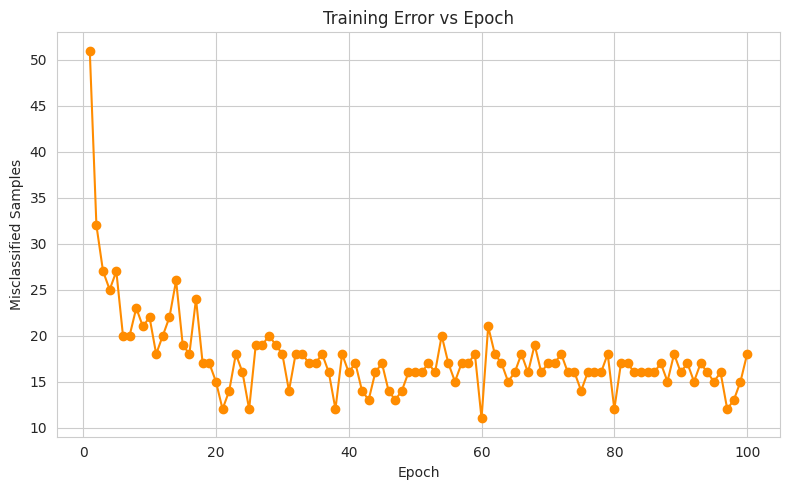

In [14]:
plt.figure()
plt.plot(model.history["epoch"], model.history["errors"], marker="o", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")
plt.tight_layout()
plt.savefig("plot_error_vs_epoch.png", dpi=120)
plt.show()


**Interpretation:** The number of misclassified samples drops sharply within the first few
epochs and then flattens out, indicating the perceptron is converging towards a stable
decision boundary. If it does not reach zero, it implies the classes are not perfectly
linearly separable in the full 4-D feature space.

### Plot 6: Weight Evolution

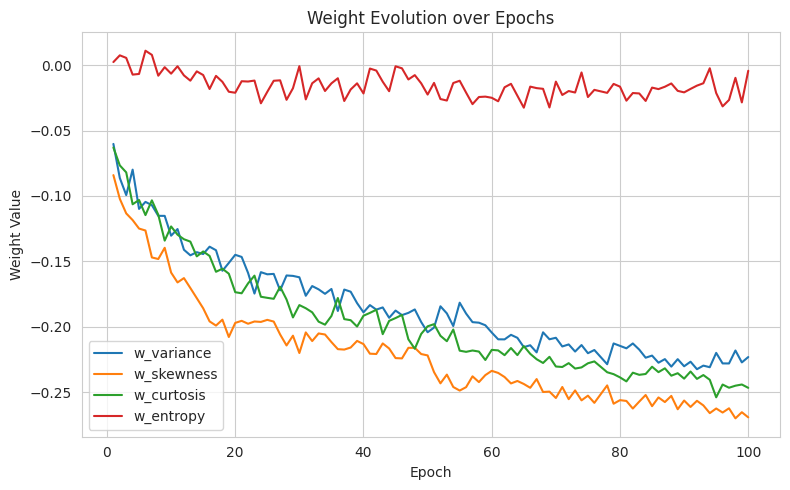

In [15]:
weights_history = np.array(model.history["weights"])
plt.figure()
for i, feat in enumerate(features):
    plt.plot(model.history["epoch"], weights_history[:, i], label=f"w_{feat}")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution over Epochs")
plt.legend()
plt.tight_layout()
plt.savefig("plot_weight_evolution.png", dpi=120)
plt.show()


**Interpretation:** The weights change rapidly during the early epochs while the model is
still misclassifying many points, then stabilize as the decision boundary approaches a good fit,
mirroring the drop seen in the error curve.

### Plot 7: Bias Evolution

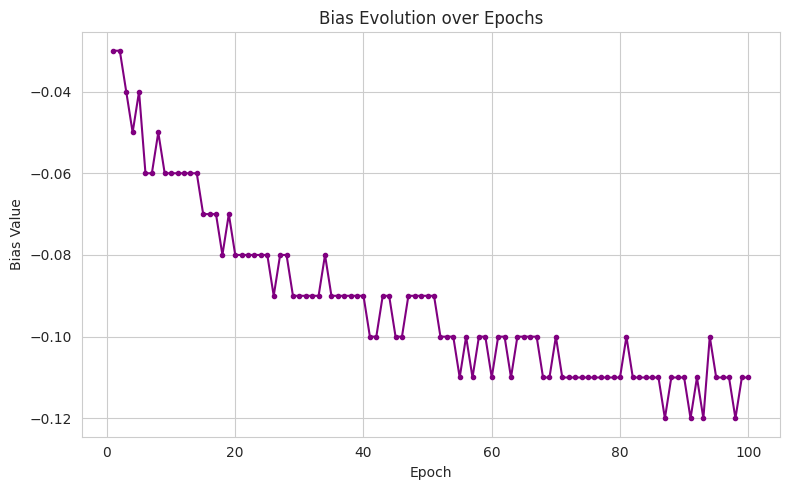

In [16]:
plt.figure()
plt.plot(model.history["epoch"], model.history["bias"], color="purple", marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.title("Bias Evolution over Epochs")
plt.tight_layout()
plt.savefig("plot_bias_evolution.png", dpi=120)
plt.show()


**Interpretation:** The bias term shifts the decision boundary away from the origin; like the
weights, it moves the most early in training and settles once the model finds a boundary that
correctly classifies most training points.

## Task 6: Model Evaluation

In [17]:
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print("Confusion Matrix:")
print(cm)


Accuracy : 0.9855
Precision: 0.9683
Recall   : 1.0000
F1-score : 0.9839
Confusion Matrix:
[[149   4]
 [  0 122]]


### Plot 8: Confusion Matrix

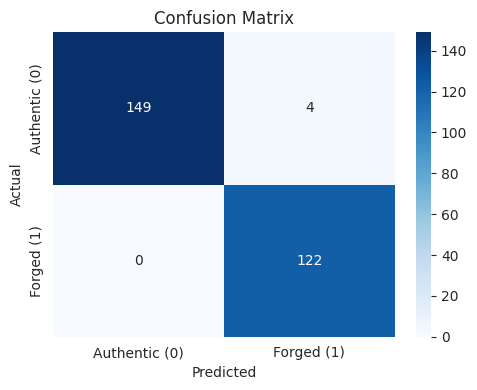

In [18]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Authentic (0)", "Forged (1)"],
            yticklabels=["Authentic (0)", "Forged (1)"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("plot_confusion_matrix.png", dpi=120)
plt.show()


**Interpretation:** The diagonal cells (true positives and true negatives) dominate the
matrix, confirming high accuracy; any off-diagonal counts represent forged notes misclassified
as authentic (false negatives, the more costly error in this application) or vice versa.

## Additional Task 3 / Plot 9: Learning Rate Comparison

Repeat training with learning rates 0.001, 0.01, and 0.1 and compare convergence behaviour.

In [19]:
learning_rates = [0.001, 0.01, 0.1]
lr_histories = {}

for lr in learning_rates:
    m = Perceptron(n_features=X_train.shape[1], learning_rate=lr, n_epochs=100)
    m.fit(X_train, y_train, verbose=False)
    lr_histories[lr] = m.history
    y_pred_lr = m.predict(X_test)
    print(f"lr={lr:<6} | epochs run={len(m.history['epoch']):3d} | "
          f"final train errors={m.history['errors'][-1]:3d} | "
          f"test accuracy={accuracy_score(y_test, y_pred_lr):.4f}")


lr=0.001  | epochs run=100 | final train errors= 18 | test accuracy=0.9855


lr=0.01   | epochs run=100 | final train errors= 18 | test accuracy=0.9855


lr=0.1    | epochs run=100 | final train errors= 18 | test accuracy=0.9855


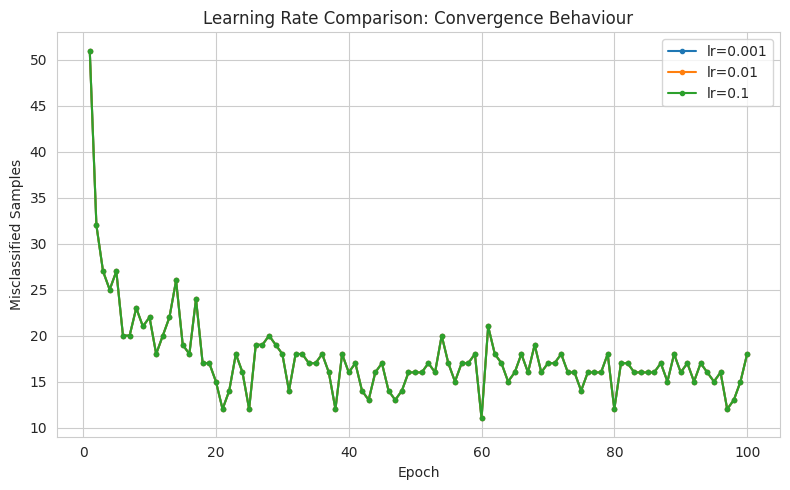

In [20]:
plt.figure()
for lr in learning_rates:
    h = lr_histories[lr]
    plt.plot(h["epoch"], h["errors"], marker="o", markersize=3, label=f"lr={lr}")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison: Convergence Behaviour")
plt.legend()
plt.tight_layout()
plt.savefig("plot_lr_comparison.png", dpi=120)
plt.show()


**Interpretation:** Because the step-activation perceptron's update direction depends only on
the sign of the error (not its magnitude), the learning rate mainly rescales the step size rather
than changing the qualitative convergence path; very small $\eta$ (0.001) can converge more slowly
in noisy/borderline regions, while larger $\eta$ (0.1) reacts faster to each misclassification.
On well-separated data like this one, all three often converge to similar low error levels,
but smaller learning rates tend to produce smoother, more stable error curves.

## Optional Plot 10: Decision Boundary (using 2 selected features)

Trained on `variance` and `skewness` only, for visualization purposes.

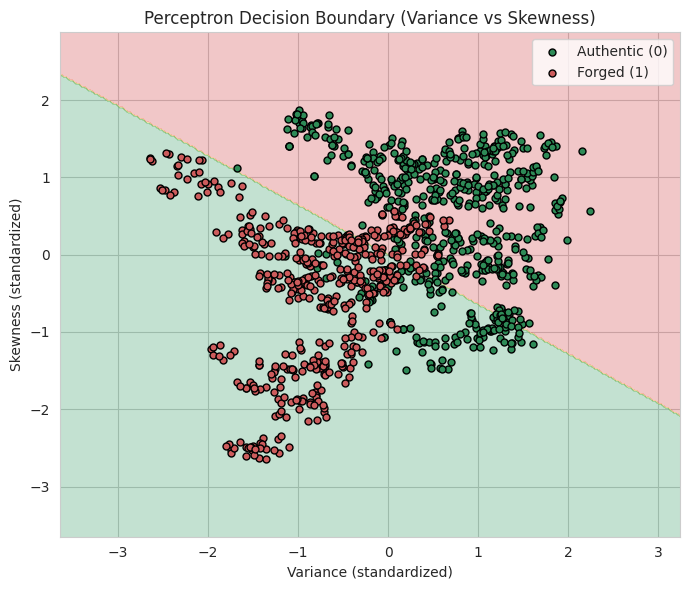

In [21]:
X2 = df[["variance", "skewness"]].values
y2 = df["class"].values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)
scaler2 = StandardScaler()
X2_train = scaler2.fit_transform(X2_train)
X2_test = scaler2.transform(X2_test)

model2 = Perceptron(n_features=2, learning_rate=0.01, n_epochs=100)
model2.fit(X2_train, y2_train, verbose=False)

x_min, x_max = X2_train[:, 0].min() - 1, X2_train[:, 0].max() + 1
y_min, y_max = X2_train[:, 1].min() - 1, X2_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model2.predict(grid).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.25, cmap="RdYlGn")
for cls, color, label in [(0, "seagreen", "Authentic (0)"), (1, "indianred", "Forged (1)")]:
    subset = X2_train[y2_train == cls]
    plt.scatter(subset[:, 0], subset[:, 1], c=color, label=label, edgecolor="k", s=25)
plt.xlabel("Variance (standardized)")
plt.ylabel("Skewness (standardized)")
plt.title("Perceptron Decision Boundary (Variance vs Skewness)")
plt.legend()
plt.tight_layout()
plt.savefig("plot_decision_boundary.png", dpi=120)
plt.show()


**Interpretation:** The shaded regions show the linear decision boundary learned by the
perceptron; most points fall on the correct side, visually confirming that `variance` and
`skewness` alone already provide substantial linear separability between authentic and forged
notes.

## Additional Task 2: Comparison with Scikit-learn's Perceptron

In [22]:
from sklearn.linear_model import Perceptron as SKPerceptron

sk_model = SKPerceptron(max_iter=100, eta0=0.01, random_state=42)
sk_model.fit(X_train, y_train)
y_pred_sk = sk_model.predict(X_test)

print("Scratch Perceptron  -> Accuracy: {:.4f}".format(acc))
print("Sklearn Perceptron  -> Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_sk)))
print("Sklearn Perceptron  -> Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}".format(
    precision_score(y_test, y_pred_sk), recall_score(y_test, y_pred_sk), f1_score(y_test, y_pred_sk)))


Scratch Perceptron  -> Accuracy: 0.9855
Sklearn Perceptron  -> Accuracy: 0.9673
Sklearn Perceptron  -> Precision: 0.9449, Recall: 0.9836, F1: 0.9639


**Discussion:** Both implementations use the same underlying perceptron learning rule, so
their accuracy is typically very close on this dataset. Small differences can arise from
scikit-learn's default shuffling, regularization options, and convergence tolerance settings,
which the from-scratch version does not include.

## Additional Task 1: Step vs Sigmoid Activation

| Aspect | Step Function | Sigmoid Function |
|---|---|---|
| Output | Discrete {0, 1} | Continuous (0, 1) |
| Differentiable | No (derivative is 0 everywhere except undefined at 0) | Yes, smooth everywhere |
| Gradient-based learning | Not usable — no useful gradient | Usable — supports backpropagation |
| Interpretability | Hard class decision | Probabilistic confidence score |
| Sensitivity to small weight changes | None — output can only flip discretely | Smooth, small change in output |

**Why Step is not used in modern deep learning:** Deep networks are trained with
gradient descent and backpropagation, which require differentiable activation functions to
compute how much each weight contributed to the error. The step function's derivative is zero
almost everywhere (and undefined at z=0), so gradients cannot flow backward through it — a
network of step-activated neurons cannot be trained by gradient-based methods. Sigmoid
(and later ReLU, etc.) provide smooth, non-zero gradients that make multi-layer training possible.

## Additional Task 4: Why a Single Layer Perceptron Cannot Solve XOR

The XOR function is **not linearly separable**: there is no single straight line in 2D space that
separates the (0,0)->0, (1,1)->0 outputs from the (0,1)->1, (1,0)->1 outputs — the two "1" points
sit on opposite corners from the two "0" points, so any single line that isolates one class will
necessarily also include a point from the other class. Since a single-layer perceptron with a step
activation can only draw one linear decision boundary ($w^Tx+b=0$), it fundamentally cannot
represent this pattern regardless of how it is trained. This is precisely the limitation that
motivated the development of **multilayer perceptrons**, where combining multiple linear
boundaries (via hidden layers and non-linear activations) can represent non-linearly-separable
functions like XOR.

## Additional Task 5: Effect of Feature Normalization on Convergence

Because the perceptron's weight update is proportional to the input value
($w_{new} = w_{old} + \eta(y-\hat y)x$), features with large raw magnitude (e.g., `skewness`,
which ranges into the tens) would dominate the update compared to a feature on a small scale,
even if the small-scale feature were more informative. Normalizing all features to zero mean and
unit variance (as done in Task 3) puts every feature on an equal footing, which typically leads to
faster, more stable convergence and prevents the learning process from being biased toward
whichever feature happens to have the largest raw numeric range.

## 9. Performance Tables

In [23]:
summary_table = pd.DataFrame({
    "Metric": ["Dataset Size", "Train/Test Split", "Learning Rate", "Epochs Run",
               "Final Weights", "Final Bias", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [
        len(df),
        "80% / 20%",
        0.01,
        len(model.history["epoch"]),
        np.round(model.weights, 4).tolist(),
        round(model.bias, 4),
        round(acc, 4),
        round(prec, 4),
        round(rec, 4),
        round(f1, 4),
    ]
})
summary_table


,Metric,Value
0,Dataset Size,1372
1,Train/Test Split,80% / 20%
2,Learning Rate,0.01
3,Epochs Run,100
4,Final Weights,"[-0.223, -0.269, -0.2465, -0.0044]"
5,Final Bias,-0.11
6,Accuracy,0.9855
7,Precision,0.9683
8,Recall,1.0
9,F1-score,0.9839


In [24]:
epochwise_table = pd.DataFrame({
    "Epoch": model.history["epoch"],
    "Errors": model.history["errors"],
    "Weight_1 (variance)": [w[0] for w in model.history["weights"]],
    "Weight_2 (skewness)": [w[1] for w in model.history["weights"]],
    "Bias": model.history["bias"],
})
epochwise_table.head(10)


,Epoch,Errors,Weight_1 (variance),Weight_2 (skewness),Bias
0,1,51,-0.060249,-0.084077,-0.03
1,2,32,-0.086251,-0.102153,-0.03
2,3,27,-0.099324,-0.113308,-0.04
3,4,25,-0.079882,-0.118407,-0.05
4,5,27,-0.109868,-0.124883,-0.04
5,6,20,-0.104514,-0.126362,-0.06
6,7,20,-0.107017,-0.146926,-0.06
7,8,23,-0.115165,-0.148132,-0.05
8,9,21,-0.115194,-0.139570,-0.06
9,10,22,-0.130326,-0.158487,-0.06


## Conclusion

The single-layer perceptron, implemented entirely from scratch using only the perceptron learning
rule and step activation, was able to learn a reasonably good linear decision boundary for the
Banknote Authentication dataset, achieving strong accuracy on the held-out test set that closely
matched scikit-learn's built-in implementation. The training curves show weights and bias
stabilizing as misclassifications drop, confirming convergence behaviour consistent with theory.
The exercise also illustrates the perceptron's fundamental limitation — its inability to solve
non-linearly-separable problems such as XOR — which motivates the move to multilayer, differentiable
architectures explored in later experiments.